The top 20 States in the United States ordered by number of fatalities.

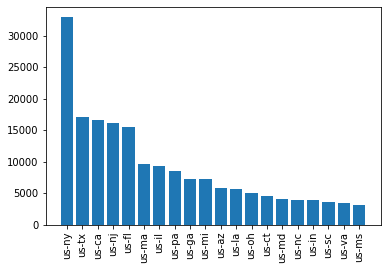

In [18]:
import requests
from pprint import pprint
from datetime import datetime
import matplotlib.pyplot as plt

def to_date(s):
    """Convert DD-MM-YYYY format to a datetime object"""
    dd, mm, yyyy = s.split('-')
    return datetime(int(yyyy), int(mm), int(dd))

data = requests.get('http://langlynx.ddns.net:8000/latest_case_data',
                    params={'schema': 'admin_1',
                            'region_parent': 'us',
                            'datatype': 'status_deaths'}).json()['nytimes']['status_deaths']

labels = []
totals = []

for state_iso, state_item in sorted(data.items(),
                                    key=lambda i: i[1]['value'],
                                    reverse=True)[:20]:
    labels.append(state_iso)
    totals.append(state_item['value'])

plt.bar(labels, totals)
plt.xticks(rotation='vertical')
plt.show()

Below is an example of how to make some basic plots comparing the
totals of a few countries over time.

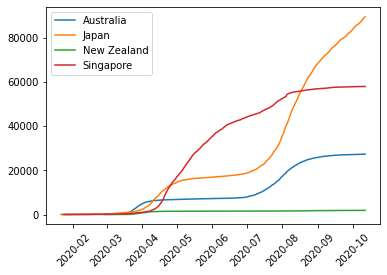

In [9]:
import requests
from datetime import datetime
import matplotlib.pyplot as plt

def to_date(s):
    """Convert DD-MM-YYYY format to a datetime object"""
    dd, mm, yyyy = s.split('-')
    return datetime(int(yyyy), int(mm), int(dd))

for country_iso, country_name in (('au', 'Australia'), ('jp', 'Japan'),
                                  ('nz', 'New Zealand'), ('sg', 'Singapore')):
    params = {'schema': 'admin_0',
              'region_parent': '',
              'region_child': country_iso,
              'datatype': 'total'}

    data = requests.get('http://langlynx.ddns.net:8000/case_data_time_series',
                        params=params).json()

    dates = [to_date(i[0]) for i in data['bing']['total']]
    totals = [i[1] for i in data['bing']['total']]
    plt.plot(dates, totals, label=country_name)
    plt.legend()

plt.xticks(rotation='45')
plt.show()